# 04 — Алгоритмическая справедливость (COMPAS)

COMPAS (ProPublica, округ Брауард, Флорида) — канонический датасет для исследования предвзятости в инструментах оценки риска рецидива (Chouldechova 2017; Rudin et al. 2020).

Здесь валидируются fairness-метрики проекта и демонстрируется метод митигации (`ThresholdOptimizer`, Hardt et al. 2016 — пост-обработка под equalized odds). Анализ — по бинарному признаку расы (Afro-American vs Caucasian), как в работе Chouldechova.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

from recidivism.baselines import make_baselines
from recidivism.data import prepare_compas
from recidivism.metrics import classification_metrics, fairness_gaps, group_fairness_table

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

X, y, race = prepare_compas("../data/raw/compas-scores-two-years.csv")

# Бинарный анализ: две крупнейшие группы, как в Chouldechova (2017)
mask = race.isin(["African-American", "Caucasian"]).to_numpy()
X, y, race = X[mask].reset_index(drop=True), y[mask], race[mask].reset_index(drop=True)

X_tr, X_te, y_tr, y_te, race_tr, race_te = train_test_split(
    X, y, race, test_size=0.3, stratify=y, random_state=42)
print("train:", X_tr.shape, "| test:", X_te.shape)
print(race_te.value_counts())

train: (3694, 7) | test: (1584, 7)
race
African-American    947
Caucasian           637
Name: count, dtype: int64


In [2]:
# Базовая модель (XGBoost) и fairness-отчёт по расе
model = make_baselines(seed=42)["xgboost"]
model.fit(X_tr, y_tr)
p_te = model.predict_proba(X_te)[:, 1]

print("Качество:", {k: round(v, 4) for k, v in classification_metrics(y_te, p_te).items()})

table = group_fairness_table(y_te, p_te, race_te)
display(table.round(4))
print("Разрывы:", {k: round(v, 4) for k, v in fairness_gaps(table).items()})

Качество: {'roc_auc': 0.6947, 'f1': 0.6036, 'accuracy': 0.6484, 'precision': 0.6424, 'recall': 0.5691, 'brier': 0.2252, 'ece': 0.0593}


,n,base_rate,selection_rate,auc,fpr,fnr,ece
group,,,,,,,
African-American,947,0.5238,0.5005,0.7098,0.3370,0.3508,0.0569
Caucasian,637,0.3909,0.2920,0.6461,0.2165,0.5904,0.0885


Разрывы: {'demographic_parity_diff': 0.2085, 'equalized_odds_diff': 0.2396, 'auc_gap': 0.0637, 'calibration_gap': 0.0316}


In [3]:
# Митигация: пост-обработка порогов под equalized odds (Hardt et al., 2016)
import numpy as np
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin


class Float64ProbaWrapper(BaseEstimator, ClassifierMixin):
    """fairlearn 0.14 падает на float32-вероятностях XGBoost (pandas 3.0) —
    приводим вывод predict_proba к float64."""

    def __init__(self, m):
        self.m = m
        self.classes_ = np.array([0, 1])

    def fit(self, *a, **k):
        return self

    def predict(self, X):
        return self.m.predict(X)

    def predict_proba(self, X):
        return np.asarray(self.m.predict_proba(X), dtype=np.float64)

    def __sklearn_is_fitted__(self):
        return True


postproc = ThresholdOptimizer(
    estimator=Float64ProbaWrapper(model),
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True,
    predict_method="predict_proba",
)
postproc.fit(X_tr, y_tr, sensitive_features=race_tr)
y_pred_fair = postproc.predict(X_te, sensitive_features=race_te, random_state=42)

table_fair = group_fairness_table(y_te, y_pred_fair.astype(float), race_te)
display(table_fair.round(4))
print("Разрывы после митигации:", {k: round(v, 4) for k, v in fairness_gaps(table_fair).items()})

,n,base_rate,selection_rate,auc,fpr,fnr,ece
group,,,,,,,
African-American,947,0.5238,0.5502,0.6505,0.3925,0.3065,0.3474
Caucasian,637,0.3909,0.4835,0.5877,0.4149,0.4096,0.4129


Разрывы после митигации: {'demographic_parity_diff': 0.0666, 'equalized_odds_diff': 0.1032, 'auc_gap': 0.0628, 'calibration_gap': 0.0655}


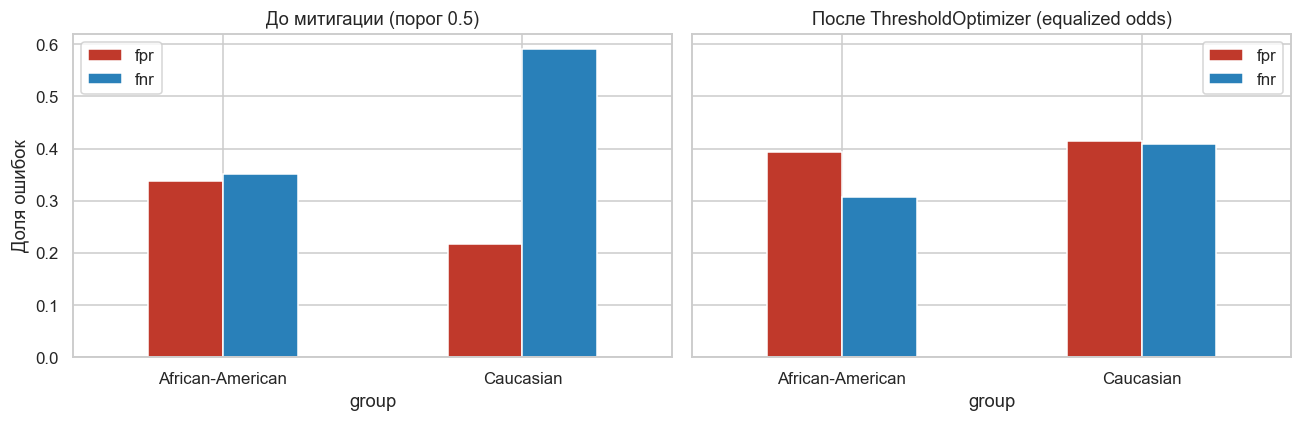

In [4]:
# Визуализация: FPR/FNR по группам до и после митигации
y_pred_base = (p_te >= 0.5).astype(float)

def rates(table):
    return table[["fpr", "fnr"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
rates(group_fairness_table(y_te, y_pred_base, race_te)).plot(kind="bar", ax=axes[0], color=["#c0392b", "#2980b9"])
axes[0].set_title("До митигации (порог 0.5)")
rates(table_fair).plot(kind="bar", ax=axes[1], color=["#c0392b", "#2980b9"])
axes[1].set_title("После ThresholdOptimizer (equalized odds)")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylabel("Доля ошибок")
plt.tight_layout()
plt.show()

## Выводы

- Без вмешательства модель воспроизводит известную асимметрию COMPAS: для афроамериканской группы выше FPR (ложные обвинения в будущем рецидиве), для европеоидной — выше FNR.
- Пост-обработка порогов (`ThresholdOptimizer`) существенно сокращает разрыв equalized odds ценой небольшой потери точности — это иллюстрация фундаментального trade-off Chouldechova (2017).
- В гибридной модели диссертации эти же метрики применяются к NIJ-датасету (`scripts/run_experiments.py`); на 2-м году обучения планируется сравнение pre-/in-/post-processing методов митигации.